### Load Data (˶˃ ᵕ ˂˶)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
books = pd.read_csv("../data/raw/BX-Books.csv", sep=";", encoding="latin-1", on_bad_lines="skip")
users = pd.read_csv("../data/raw/BX-Users.csv", sep=";", encoding="latin-1")
ratings = pd.read_csv("../data/raw/BX-Book-Ratings.csv", sep=";", encoding="latin-1")

/var/folders/vk/vb59k9cj2f9gk6brqmlly3c00000gn/T/com.apple.shortcuts.mac-helper/ipykernel_5681/2468744509.py:1: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("../data/raw/BX-Books.csv", sep=";", encoding="latin-1", on_bad_lines="skip")


### EDA ✎𓂃

#### Books dataset 

⭐️ inference:
- ISBN values are all unique 
    - can be used as PK
- There are missing Book-Author and Publisher names 
    - kept or removed? ✅
- There are ~30K duplicate Book-Title 
    - could be different editions (diff. ISBN so shouldn't matter)
- Year-of-publication is object?? why?
- Do we need Image URLs for recommendation? ✅

⭐️ Issues with Year-of-publication:
1. Mixed data types (int and str)
2. year 0, 2037??
3. publisher and author names mixed in - 'DK Publishing Inc' and 'Gallimard' (3 entries)

✅ standardise data type and remove/fix dirty entries

In [4]:
books.info()
books.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  str   
 1   Book-Title           271360 non-null  str   
 2   Book-Author          271358 non-null  str   
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  str   
 5   Image-URL-S          271360 non-null  str   
 6   Image-URL-M          271360 non-null  str   
 7   Image-URL-L          271357 non-null  str   
dtypes: object(1), str(7)
memory usage: 83.4+ MB


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
count,271360,271360,271358,271360,271358,271360,271360,271357
unique,271360,242135,102022,202,16807,271044,271044,271041
top,0195153448,Selected Poems,Agatha Christie,2002,Harlequin,http://images.amazon.com/images/P/042511774X.0...,http://images.amazon.com/images/P/042511774X.0...,http://images.amazon.com/images/P/042511774X.0...
freq,1,27,632,13903,7535,2,2,2


In [5]:
books.isna().sum() # missing values

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [6]:
books[books["Book-Author"].isna()] # entries with missing authors

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...


In [7]:
books[books["Publisher"].isna()] # entries with missing publishers

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
128890,193169656X,Tyrant Moon,Elaine Corvidae,2002,NaN,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...,http://images.amazon.com/images/P/193169656X.0...
129037,1931696993,Finders Keepers,Linnea Sinclair,2001,NaN,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...,http://images.amazon.com/images/P/1931696993.0...


In [8]:
duplicates = books[books["Book-Title"].duplicated(keep=False)]
duplicates.sort_values("Book-Title").head(10)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
75637,1565920465,!%@ (A Nutshell handbook),Donnalyn Frey,1994,O'Reilly,http://images.amazon.com/images/P/1565920465.0...,http://images.amazon.com/images/P/1565920465.0...,http://images.amazon.com/images/P/1565920465.0...
156341,1565920317,!%@ (A Nutshell handbook),Donnalyn Frey,1993,O'Reilly,http://images.amazon.com/images/P/1565920317.0...,http://images.amazon.com/images/P/1565920317.0...,http://images.amazon.com/images/P/1565920317.0...
140618,0792276833,'A Hell of a Place to Lose a Cow': An American...,Tim Brookes,2000,National Geographic,http://images.amazon.com/images/P/0792276833.0...,http://images.amazon.com/images/P/0792276833.0...,http://images.amazon.com/images/P/0792276833.0...
158204,0792277295,'A Hell of a Place to Lose a Cow': An American...,Tim Brookes,2001,National Geographic,http://images.amazon.com/images/P/0792277295.0...,http://images.amazon.com/images/P/0792277295.0...,http://images.amazon.com/images/P/0792277295.0...
10438,0451168089,'Salem's Lot,Stephen King,1990,Signet Book,http://images.amazon.com/images/P/0451168089.0...,http://images.amazon.com/images/P/0451168089.0...,http://images.amazon.com/images/P/0451168089.0...
22024,067103975X,'Salem's Lot,Stephen King,2000,Pocket,http://images.amazon.com/images/P/067103975X.0...,http://images.amazon.com/images/P/067103975X.0...,http://images.amazon.com/images/P/067103975X.0...
94187,0385007515,'Salem's Lot,Stephen King,1993,Doubleday Books,http://images.amazon.com/images/P/0385007515.0...,http://images.amazon.com/images/P/0385007515.0...,http://images.amazon.com/images/P/0385007515.0...
105639,0690091184,...And Now Miguel,Joseph Krumgold,1953,HarperCollins,http://images.amazon.com/images/P/0690091184.0...,http://images.amazon.com/images/P/0690091184.0...,http://images.amazon.com/images/P/0690091184.0...
249713,006440143X,...And Now Miguel,Joseph Krumgold,1984,HarperTrophy,http://images.amazon.com/images/P/006440143X.0...,http://images.amazon.com/images/P/006440143X.0...,http://images.amazon.com/images/P/006440143X.0...
142204,1567315070,"1,003 Great Things About Teachers",Birnbach,2002,MJF Books,http://images.amazon.com/images/P/1567315070.0...,http://images.amazon.com/images/P/1567315070.0...,http://images.amazon.com/images/P/1567315070.0...


In [9]:
books["Year-Of-Publication"].describe()
# books["Year-Of-Publication"].unique()

count     271360
unique       202
top         2002
freq       13903
Name: Year-Of-Publication, dtype: int64

In [10]:
books[
    books["Year-Of-Publication"].isin(
        ["DK Publishing Inc", "Gallimard"]
    )
]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
209538,078946697X,"DK Readers: Creating the X-Men, How It All Beg...",2000,DK Publishing Inc,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,http://images.amazon.com/images/P/078946697X.0...,NaN
220731,2070426769,"Peuple du ciel, suivi de 'Les Bergers\"";Jean-M...",2003,Gallimard,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,http://images.amazon.com/images/P/2070426769.0...,NaN
221678,0789466953,"DK Readers: Creating the X-Men, How Comic Book...",2000,DK Publishing Inc,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,http://images.amazon.com/images/P/0789466953.0...,NaN


#### Users dataset

⭐️ notes
- User-ID is unique
    - can serve as PK
- location can be split into three (City, State, Country)
    - ~4.5K users have missing or malformed country information
    - not required for collaborative filtering; can be used for regional recomm.
- age has (~111K / ~278K) missing and invalid entries (~40% of entries)
    - investigate if there is a correlation

In [11]:
users.info()
# users.describe(include="all")
users.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  str    
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 13.4 MB


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [12]:
# Duplicate user IDs
users["User-ID"].duplicated().sum()

np.int64(0)

In [13]:
# Extract country
users["Country"] = users["Location"].str.split(",").str[-1].str.strip()
users["Country"].value_counts().head(20)

Country
usa               139711
canada             21658
united kingdom     18538
germany            17043
spain              13147
australia          11784
italy              11266
                    4578
france              3455
portugal            3325
new zealand         3097
netherlands         3025
switzerland         1745
brazil              1674
china               1488
sweden              1406
india               1290
austria             1136
malaysia            1119
argentina           1083
Name: count, dtype: int64

In [14]:
# users[users["Country"] == ""]
(users["Country"] == "").sum()

np.int64(4578)

In [15]:
# Missing ages
users["Age"].isna().sum()

np.int64(110762)

In [16]:
# Invalid ages
((users["Age"] < 5) | (users["Age"] > 100)).sum()

np.int64(1248)

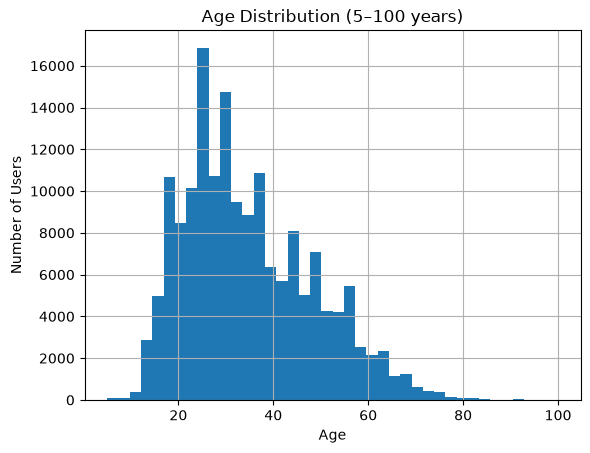

In [17]:
users.loc[users["Age"].between(5, 100), "Age"].hist(bins=40)

plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.title("Age Distribution (5–100 years)")
plt.show()

#### Ratings Dataset

⭐️ notes:
- *long tail distribution and sparcity*
    - a few users/books dominate the interaction cause a huge skewness between the data points.
    - cold-start problem / sparse matrix
- dataset has all unique User-ID:ISBN values 
    - Includes users:books those haven't been rated/ rated 0 (implicit rating)
        - ~716K out of ~1149K entries (~62%)
        - considering explicit ratings alone injects positivity bias (ignored for this project)

In [30]:
ratings.info()
ratings.describe(include="all")
# ratings.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype
---  ------       --------------    -----
 0   User-ID      1149780 non-null  int64
 1   ISBN         1149780 non-null  str  
 2   Book-Rating  1149780 non-null  int64
dtypes: int64(2), str(1)
memory usage: 37.3 MB


,User-ID,ISBN,Book-Rating
count,1.149780e+06,1149780,1.149780e+06
unique,NaN,340556,NaN
top,NaN,0971880107,NaN
freq,NaN,2502,NaN
mean,1.403864e+05,NaN,2.866950e+00
std,8.056228e+04,NaN,3.854184e+00
min,2.000000e+00,NaN,0.000000e+00
25%,7.034500e+04,NaN,0.000000e+00
50%,1.410100e+05,NaN,0.000000e+00
75%,2.110280e+05,NaN,7.000000e+00


In [31]:
ratings.duplicated(
    subset=["User-ID", "ISBN"]
).sum()

np.int64(0)

In [32]:
#most active users
ratings["User-ID"].value_counts().head(10)

User-ID
11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
212898     4785
278418     4533
76352      3367
110973     3100
235105     3067
Name: count, dtype: int64

In [33]:
# number of ratings per user
ratings_per_user = ratings.groupby("User-ID").size()
ratings_per_user.describe()

count    105283.000000
mean         10.920851
std          90.562825
min           1.000000
25%           1.000000
50%           1.000000
75%           4.000000
max       13602.000000
dtype: float64

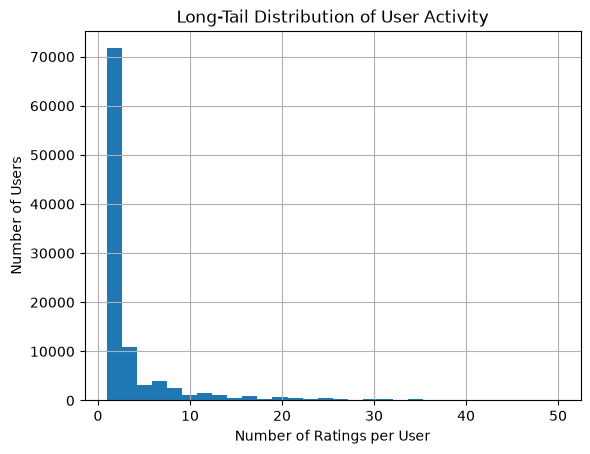

In [34]:
ratings_per_user[ratings_per_user <= 50].hist(bins=30)

plt.xlabel("Number of Ratings per User")
plt.ylabel("Number of Users")
plt.title("Long-Tail Distribution of User Activity")
plt.show()

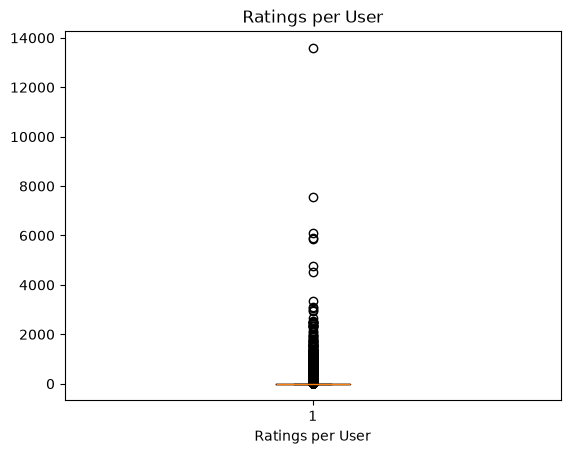

In [35]:
#visualisation of outliers
plt.boxplot(ratings_per_user)

plt.xlabel("Ratings per User")
plt.title("Ratings per User")
plt.show()

In [36]:
# number of ratings per book
ratings_per_book = ratings.groupby("ISBN").size()
ratings_per_book.describe()

count    340556.000000
mean          3.376185
std          12.436252
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        2502.000000
dtype: float64

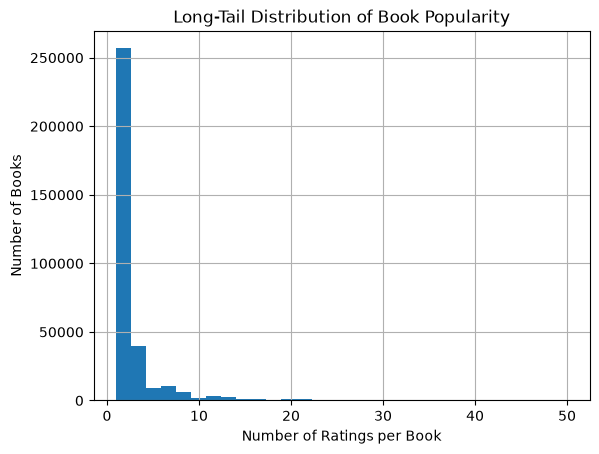

In [37]:
ratings_per_book[ratings_per_book <= 50].hist(bins=30)

plt.xlabel("Number of Ratings per Book")
plt.ylabel("Number of Books")
plt.title("Long-Tail Distribution of Book Popularity")
plt.show()

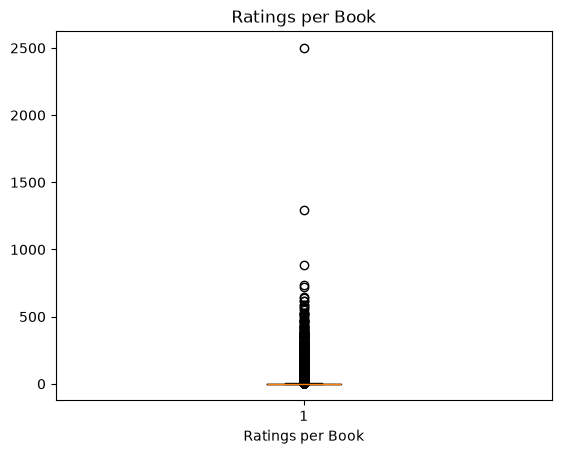

In [38]:
# visualisation of outliers
plt.boxplot(ratings_per_book)

plt.xlabel("Ratings per Book")
plt.title("Ratings per Book")
plt.show()

In [39]:
ratings["Book-Rating"].value_counts().sort_index()

Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64

In [40]:
explicit = (ratings["Book-Rating"] > 0).sum()
implicit = (ratings["Book-Rating"] == 0).sum()

print(explicit, implicit)

433671 716109


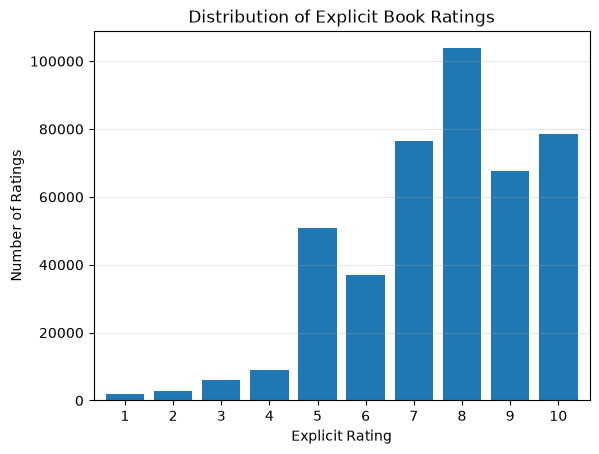

In [41]:
rating_counts = (
    ratings.loc[ratings["Book-Rating"] > 0, "Book-Rating"]
    .value_counts()
    .sort_index()
)

rating_counts.plot(kind="bar", width=0.8)

plt.xlabel("Explicit Rating")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Explicit Book Ratings")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Extra stuff

- There are ISBNs in ratings dataset that aren't there in books dataset itself. We should remove them ideally. 
- Users are all existing users- no worries.

In [42]:
# Unique ISBNs
book_isbns = set(books["ISBN"])
rating_isbns = set(ratings["ISBN"])

# Missing ISBNs
missing_isbns = rating_isbns - book_isbns

print(f"Unique ISBNs in books   : {len(book_isbns):,}")
print(f"Unique ISBNs in ratings : {len(rating_isbns):,}")
print(f"Missing ISBNs           : {len(missing_isbns):,}")

Unique ISBNs in books   : 271,360
Unique ISBNs in ratings : 340,556
Missing ISBNs           : 70,405


In [44]:
ratings[ratings["ISBN"].isin(missing_isbns)].head(10)

,User-ID,ISBN,Book-Rating
6,276736,3257224281,8
7,276737,0600570967,6
9,276745,342310538,10
25,276748,3442437407,0
26,276751,033390804X,0
30,276760,8440682697,10
39,276762,3404611306,0
40,276762,342662429,0
45,276762,3453157745,0
48,276762,3453185323,0


In [45]:
# Unique User IDs
user_ids = set(users["User-ID"])
rating_users = set(ratings["User-ID"])

# Missing User IDs
missing_users = rating_users - user_ids

print(f"Unique users in users   : {len(user_ids):,}")
print(f"Unique users in ratings : {len(rating_users):,}")
print(f"Missing users           : {len(missing_users):,}")

Unique users in users   : 278,858
Unique users in ratings : 105,283
Missing users           : 0
